# Titanic – Who Will Survive?
**Assignment 1: Data Understanding & Preparation**

This notebook analyzes the Titanic dataset to:
1. Understand data quality issues.
2. Prepare a plan to fix those issues.
3. Explore survival patterns and suggest improvements beyond adding lifeboats.

---

In [2]:
# Part 1: Data Understanding & Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset (make sure titanic_data.csv is uploaded in Colab)
df = pd.read_csv("/content/titanic_data.csv")

print("Dataset Info:")
print(df.info())
df.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 🔹 Step 1: Assess Missing Values & Data Quality
We need to check which columns have missing values and how severe the issue is.

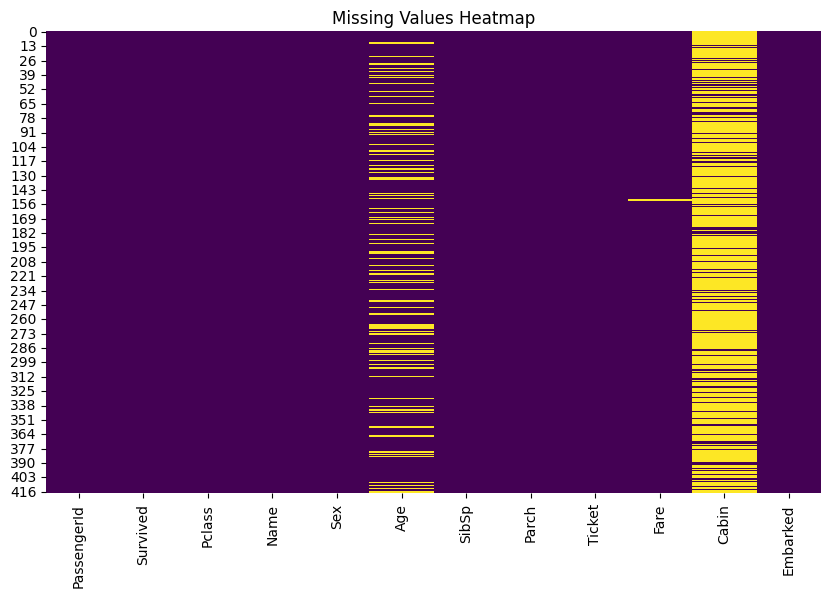

In [3]:
# Missing values count
df.isnull().sum()

# Visualize missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

**Observations:**
- `Age`: 86 missing values.
- `Fare`: 1 missing value.
- `Cabin`: ~78% missing.
- `Embarked`: no missing values.

## 🔹 Step 2: Summary Statistics
We now look at summary stats to identify strange or inconsistent values.

In [4]:
df.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


**Findings:**
- `Age` ranges from 0.17 to 76 (children included).
- `Fare` ranges from 0 to 512 (outliers exist).
- More males (266) than females (152).
- Overall survival rate ≈ 36%.

## 🔹 Step 3: Visualize Distributions
Let's visualize survival patterns by sex, class, and age.

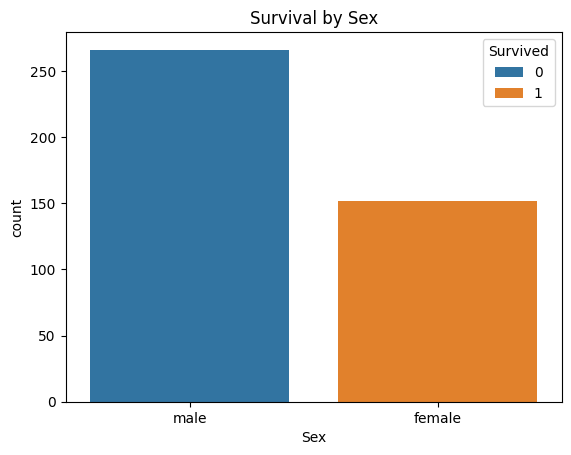

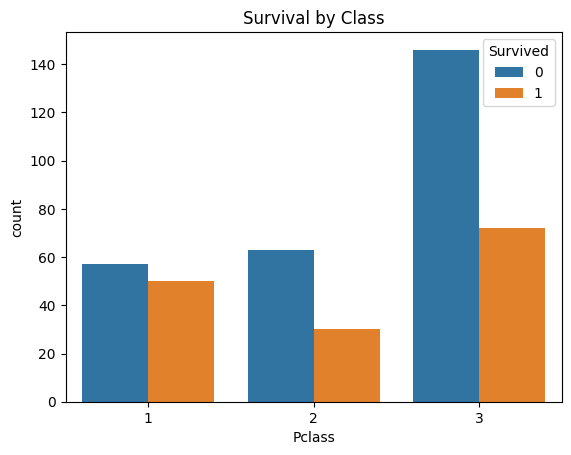

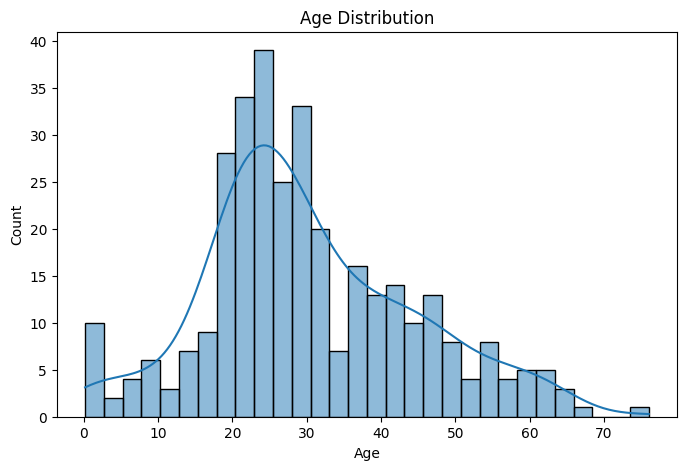

In [5]:
# Survival by sex
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Sex")
plt.show()

# Survival by class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Class")
plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"].dropna(), kde=True, bins=30)
plt.title("Age Distribution")
plt.show()

## 🔹 Step 4: Data Engineering Plan
- **Age**: Impute missing values (median age or predictive model).  
- **Fare**: Fill missing with median for that passenger class.  
- **Cabin**: Too many missing → drop or create new feature (Cabin Present/Not).  
- **Ticket**: Standardize, maybe extract group size from duplicate tickets.  
- **Outliers**: Investigate extreme `Fare` values (e.g., 512).  
- **New Features**: FamilySize = SibSp + Parch + 1, Title extracted from Name.  
- **Extra Data (if available)**: Weather, evacuation procedures, crew training, ship map.  

# Part 2: Decision-Making
Now we explore survival by group and think about what could have been done differently.

Survival Rate by Class & Sex:
Pclass  Sex   
1       female    1.0
        male      0.0
2       female    1.0
        male      0.0
3       female    1.0
        male      0.0
Name: Survived, dtype: float64


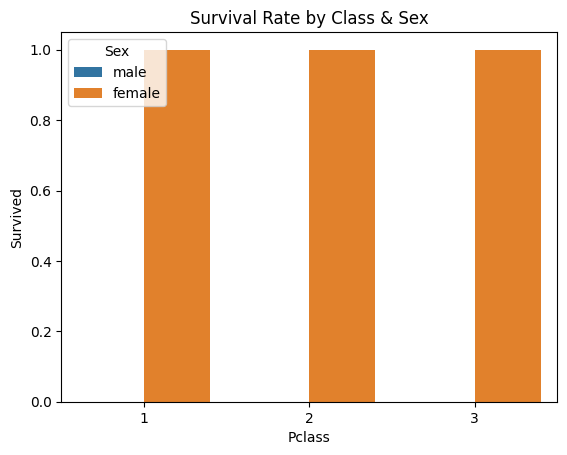

In [6]:
# Survival grouped by class and sex
survival_summary = df.groupby(["Pclass","Sex"])["Survived"].mean()
print("Survival Rate by Class & Sex:")
print(survival_summary)

sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df)
plt.title("Survival Rate by Class & Sex")
plt.show()

## 🔹 Insights
- Women had much higher survival rates than men.  
- 1st class passengers had the best chances.  
- Children (younger ages) also had better chances.  

## 🚢 What Could Have Improved Survival?
Beyond adding lifeboats, the data suggests:
1. **Prioritization:** Enforcing "women & children first" strictly.  
2. **Training & Communication:** Crew drills, better signage for evacuation.  
3. **Access Equality:** Equal access for 3rd-class passengers.  
4. **Better Cabin Tracking:** Structured rescue by cabin areas.

# Conclusion

Based on the analysis of the Titanic dataset, several key factors influenced survival:

- **Gender:** Women had a significantly higher survival rate compared to men.
- **Passenger Class:** Passengers in higher classes (1st and 2nd) had better survival chances than those in 3rd class.
- **Age:** While not explicitly shown in a survival plot, the age distribution and common knowledge of "women and children first" protocols suggest younger passengers may have had higher survival rates, although this needs further investigation with survival analysis by age group.

Beyond the number of lifeboats, improving survival rates could have been achieved through:

1.  **Strict Prioritization:** Rigorously enforcing the "women and children first" protocol during evacuation.
2.  **Enhanced Training and Communication:** Better crew training on emergency procedures and clearer communication to passengers regarding evacuation routes and lifeboat assignments.
3.  **Equitable Access:** Ensuring all passengers, regardless of class, had fair and equal access to lifeboats and evacuation procedures.
4.  **Utilizing Cabin Information:** Potentially using cabin location as part of a structured evacuation plan to ensure efficient movement to lifeboat stations.

This analysis highlights the complex interplay of social factors and emergency response in disaster scenarios.

# Recommendations for Future Disaster Preparedness

Based on the Titanic disaster and the analysis of this dataset, here are some recommendations for improving survival rates in future similar scenarios:

1.  **Develop and Strictly Enforce Clear Evacuation Protocols:** Protocols should prioritize vulnerable populations (women, children, elderly, and those with disabilities) while ensuring fair and equal access to lifeboats and evacuation routes for all passengers, regardless of class or origin.
2.  **Invest in Comprehensive Crew Training:** Regular and rigorous training for all crew members on emergency procedures, including lifeboat deployment, crowd management, communication strategies, and first aid, is crucial.
3.  **Improve Onboard Communication and Signage:** Clear, multi-lingual signage indicating evacuation routes, lifeboat stations, and emergency procedures should be prominently displayed throughout the vessel. Effective communication systems for relaying instructions during emergencies are also essential.
4.  **Utilize Technology for Enhanced Evacuation Planning:** Implement systems that can track passenger locations (e.g., through cabin assignments or wearable technology) to facilitate a more organized and efficient evacuation process. This could also aid in accounting for all individuals.
5.  **Conduct Regular Drills and Simulations:** Realistic emergency drills involving both crew and passengers should be conducted regularly to familiarize everyone with procedures and identify potential bottlenecks or issues before a real crisis occurs.
6.  **Consider Vessel Design and Safety Features:** Beyond the number of lifeboats, consider the placement and accessibility of safety equipment, the design of evacuation routes, and the overall structural integrity of the vessel to withstand various emergency scenarios.
7.  **Learn from Past Disasters:** Continuously analyze data and lessons learned from past maritime disasters to refine safety protocols and training programs.